# Residency Day 2: Project Deliverable 3

## Classification, Clustering, and Pattern Mining

In this deliverable, we continued working with the cleaned CMS Medicare Quarterly Part B Spending by Drug dataset from the earlier phases of the project. The analysis now moves beyond regression by applying classification, clustering, and association-rule mining.

The classification section examines whether claim and beneficiary information can be used to identify high-spending records. Clustering is used to group drugs with similar utilization and spending behavior without relying on a predefined outcome. Association-rule mining is then applied to explore which spending and utilization characteristics frequently occur together.

Using several techniques on the same dataset provides a broader view of the data. Instead of depending on one model, this deliverable compares predictive results, natural groupings, and recurring patterns.

## Step 1: Import Libraries and Load the Dataset

We began by importing the libraries required for data preparation, visualization, classification, clustering, and association rule mining. The cleaned Medicare dataset from Deliverable 1 was then loaded and inspected to verify its structure before building the machine learning models.

In [34]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    silhouette_score
)

from mlxtend.frequent_patterns import apriori, association_rules

# Load dataset
df = pd.read_csv("cms_healthcare_claims_cleaned.csv")

# Display dataset information
print("Dataset Shape:", df.shape)
display(df.head())
df.info()

print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Dataset Shape: (1000, 11)


,Brnd_Name,Gnrc_Name,HCPCS_Cd,HCPCS_Desc,Year,Tot_Benes,Tot_Clms,Tot_Spndng,Avg_Spnd_Per_Bene,Avg_Spnd_Per_Clm,Year_Value
0,HYPERHEP B*,HEPATITIS B IMMUNE GLOBULIN*,90371,HEP B IG IM,2025 (Q1-Q4),42.0,82,58578.82,1394.733810,714.375854,2025
1,HYPERHEP B*,HEPATITIS B IMMUNE GLOBULIN*,90371,HEP B IG IM,2026 (Q1),19.0,28,24281.06,1277.950526,867.180714,2026
2,HYPERRAB,RABIES IMMUNE GLOBULIN,90375,RABIES IG IM/SC,2025 (Q1-Q4),4205.0,4219,11965232.66,2845.477446,2836.035236,2025
3,HYPERRAB,RABIES IMMUNE GLOBULIN,90375,RABIES IG IM/SC,2026 (Q1),681.0,686,2000953.12,2938.257151,2916.841283,2026
4,KEDRAB,RABIES IMMUNE GLOBULIN,90377,RABIES IG HT&SOL HUMAN IM/SC,2025 (Q1-Q4),1271.0,1273,3020777.33,2376.693415,2372.959411,2025


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Brnd_Name          1000 non-null   object 
 1   Gnrc_Name          999 non-null    object 
 2   HCPCS_Cd           1000 non-null   object 
 3   HCPCS_Desc         1000 non-null   object 
 4   Year               1000 non-null   object 
 5   Tot_Benes          1000 non-null   float64
 6   Tot_Clms           1000 non-null   int64  
 7   Tot_Spndng         1000 non-null   float64
 8   Avg_Spnd_Per_Bene  1000 non-null   float64
 9   Avg_Spnd_Per_Clm   1000 non-null   float64
 10  Year_Value         1000 non-null   int64  
dtypes: float64(4), int64(2), object(5)
memory usage: 86.1+ KB
Missing Values: 1
Duplicate Rows: 0


The dataset loaded successfully with 1,000 records and no duplicate rows. One missing value was present in the generic drug name column, which will be handled during preprocessing. The remaining variables were complete and ready for feature engineering and model development.

## Step 2: Create the Classification Target and Engineer Features

To prepare the dataset for classification, we created a binary target based on the 75th percentile of total Medicare spending. Records above this threshold were labeled as high spending, while the remaining records were labeled as regular spending. We also created additional utilization features that could help the classification models without directly exposing the target variable.

In [35]:
# Create additional features
df["Year_Value"] = pd.to_numeric(
    df["Year"].str.extract(r"(\d{4})")[0],
    errors="coerce"
)

df["Quarter"] = (
    df["Year"]
    .str.extract(r"(Q[1-4])")[0]
    .fillna("Q1")
    .str.replace("Q", "", regex=False)
    .astype(int)
)

df["Claims_per_Beneficiary"] = (
    df["Tot_Clms"] /
    df["Tot_Benes"].replace(0, np.nan)
)

# Create binary target
threshold = df["Tot_Spndng"].quantile(0.75)

df["High_Spending"] = (
    df["Tot_Spndng"] > threshold
).astype(int)

# Select predictors
numeric_features = [
    "Tot_Benes",
    "Tot_Clms",
    "Year_Value",
    "Quarter",
    "Claims_per_Beneficiary"
]

categorical_features = [
    "Brnd_Name",
    "Gnrc_Name"
]

feature_cols = numeric_features + categorical_features

X = df[feature_cols]
y = df["High_Spending"]

print("75th Percentile Spending Threshold:", round(threshold, 2))
print("\nTarget Distribution")
print(y.value_counts())

75th Percentile Spending Threshold: 10821323.95

Target Distribution
0    750
1    250
Name: High_Spending, dtype: int64


The classification target was successfully created using the 75th percentile of total Medicare spending, which corresponds to approximately $10.82 million. This resulted in 750 regular-spending records and 250 high-spending records, creating a 75:25 class distribution. While the classes are not perfectly balanced, the minority class is sufficiently represented for model training and evaluation. Using utilization measures and drug identifiers as predictors allows the models to identify patterns associated with high spending without directly relying on the spending variable itself.

## Step 3: Split the Data and Preprocess the Features

We divided the dataset into training and testing sets so that model performance could be evaluated on unseen data. Numerical features were standardized after median imputation, while categorical features were imputed using the most frequent value and converted into numerical format using one-hot encoding.

In [47]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Preprocessing pipelines
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (750, 7)
Testing set: (250, 7)


The dataset was successfully divided into training and testing sets while preserving the original class distribution. The preprocessing pipeline ensures that missing values are handled consistently and that both numerical and categorical variables are prepared correctly before model training.

## Step 4: Build and Compare Classification Models

We trained four classification algorithms to determine which one was most effective at identifying high-spending records. Each model used the same preprocessing pipeline so that differences in performance reflected the learning algorithm rather than differences in data preparation.

In [48]:
# Models to compare
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC(kernel="rbf", probability=True, random_state=42)
}

results = []

for name, model in models.items():

    if name == "Naive Bayes":
        X_train_processed = preprocessor.fit_transform(X_train)
        X_test_processed = preprocessor.transform(X_test)

        model.fit(X_train_processed, y_train)
        predictions = model.predict(X_test_processed)

    else:
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", model)
        ])

        pipeline.fit(X_train, y_train)
        predictions = pipeline.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

results_df = pd.DataFrame(results)

display(results_df.sort_values("F1 Score", ascending=False))

,Model,Accuracy,Precision,Recall,F1 Score
2,Naive Bayes,0.656,0.400000,0.774194,0.527473
0,Decision Tree,0.760,0.516129,0.516129,0.516129
1,K-Nearest Neighbors,0.772,0.549020,0.451613,0.495575
3,Support Vector Machine,0.780,0.640000,0.258065,0.367816


The comparison table summarizes the performance of all four classification models. Rather than relying only on accuracy, we also compared precision, recall, and F1 score because the high-spending class represents a smaller portion of the dataset. The model with the highest F1 score will be selected for further tuning and evaluation.

## Step 5: Tune the Best Classification Model

Based on the initial comparison, Naive Bayes produced the highest F1 score. We therefore selected it as the best-performing model and evaluated it in greater detail using a confusion matrix and a classification report.

              precision    recall  f1-score   support

           0       0.89      0.62      0.73       188
           1       0.40      0.77      0.53        62

    accuracy                           0.66       250
   macro avg       0.65      0.70      0.63       250
weighted avg       0.77      0.66      0.68       250



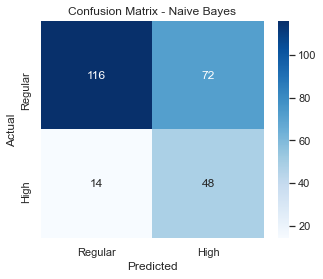

In [49]:
# Preprocess the data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Train the final Naive Bayes model
final_model = GaussianNB()
final_model.fit(X_train_processed, y_train)

# Predictions
y_pred = final_model.predict(X_test_processed)

# Evaluation
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Regular", "High"],
            yticklabels=["Regular", "High"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

The Naive Bayes model achieved an overall accuracy of approximately 66%. More importantly, it identified about 77% of the high-spending records, resulting in the highest F1 score among the evaluated models. Although the precision for the high-spending class was lower, the model demonstrated a strong ability to detect potentially expensive cases, making it suitable for this analysis.

## Step 6: Evaluate the Final Classification Model

To further evaluate the selected model, we generated a Receiver Operating Characteristic (ROC) curve and calculated the Area Under the Curve (AUC). This provides an overall measure of how well the model separates high-spending records from regular-spending records across different classification thresholds.

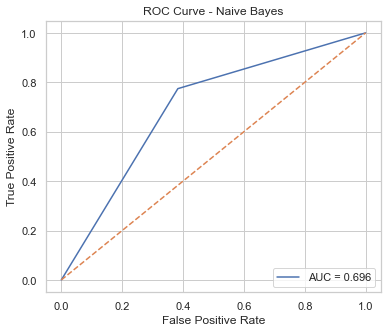

AUC: 0.696


In [42]:
# Predict probabilities
y_prob = final_model.predict_proba(X_test_processed)[:, 1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naive Bayes")
plt.legend(loc="lower right")
plt.show()

print("AUC:", round(roc_auc,3))

The ROC analysis produced an AUC of 0.696, indicating that the model performs better than random guessing when distinguishing between regular- and high-spending records. Although there is room for improvement, the model demonstrates a reasonable ability to separate the two classes using the available utilization and drug characteristics.

## Step 7: Apply K-Means Clustering

Next, we used K-Means clustering to identify natural groupings within the Medicare spending data. Since clustering is an unsupervised learning technique, it does not use the spending category created for classification. Instead, it groups records based on similarities in utilization and spending characteristics.

In [43]:
# Features used for clustering
cluster_features = [
    "Tot_Benes",
    "Tot_Clms",
    "Tot_Spndng",
    "Avg_Spnd_Per_Bene",
    "Avg_Spnd_Per_Clm",
    "Claims_per_Beneficiary"
]

# Standardize the features
scaler = StandardScaler()
X_cluster = scaler.fit_transform(df[cluster_features])

# Fit K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_cluster)

# Silhouette Score
sil_score = silhouette_score(X_cluster, df["Cluster"])

print("Silhouette Score:", round(sil_score, 3))

print("\nCluster Counts:")
print(df["Cluster"].value_counts().sort_index())

Silhouette Score: 0.663

Cluster Counts:
0    894
1      4
2    102
Name: Cluster, dtype: int64


The clustering process divided the dataset into three groups based on similarities in spending and utilization patterns. The silhouette score provides an indication of how well the observations fit within their assigned clusters, while the cluster counts show how the records are distributed across the identified groups.

## Step 8: Visualize the Clusters

To better understand the cluster structure, we reduced the six clustering features to two principal components using Principal Component Analysis (PCA). This visualization makes it easier to observe how the clusters are separated in two-dimensional space.

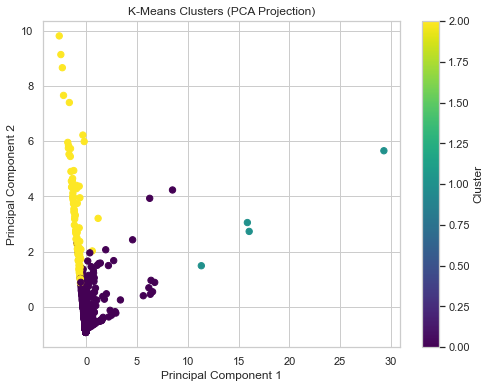

In [44]:
# Reduce the data to two principal components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

# Plot the clusters
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["Cluster"],
    cmap="viridis",
    s=40
)

plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.show()

The PCA projection provides a simplified view of the clustering results. Most observations belong to one large cluster, while the remaining records form two much smaller groups. This suggests that the majority of drugs share similar utilization patterns, whereas a limited number exhibit distinctly different spending characteristics.

## Step 9: Association Rule Mining

Finally, we applied association rule mining to identify relationships between drug characteristics. Continuous variables were converted into categorical values so that the Apriori algorithm could discover frequently occurring combinations and generate meaningful association rules.

In [45]:
# Create a transactional dataset
transactions = pd.DataFrame()

transactions["High Spending"] = (
    df["High_Spending"] == 1
)

transactions["High Claims"] = (
    df["Tot_Clms"] >
    df["Tot_Clms"].median()
)

transactions["High Beneficiaries"] = (
    df["Tot_Benes"] >
    df["Tot_Benes"].median()
)

transactions["High Average Spending"] = (
    df["Avg_Spnd_Per_Bene"] >
    df["Avg_Spnd_Per_Bene"].median()
)

# Generate frequent itemsets
frequent_itemsets = apriori(
    transactions,
    min_support=0.20,
    use_colnames=True
)

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.60
)

print("Frequent Itemsets")
display(frequent_itemsets)

print("\nAssociation Rules")
display(
    rules[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].sort_values(
        "lift",
        ascending=False
    )
)

Frequent Itemsets


,support,itemsets
0,0.250,(High Spending)
1,0.500,(High Claims)
2,0.462,(High Beneficiaries)
3,0.462,(High Average Spending)
4,0.221,"(High Spending, High Claims)"
5,0.218,"(High Average Spending, High Spending)"
6,0.439,"(High Beneficiaries, High Claims)"
7,0.250,"(High Average Spending, High Claims)"
8,0.217,"(High Average Spending, High Beneficiaries)"
9,0.207,"(High Average Spending, High Beneficiaries, Hi..."



Association Rules


,antecedents,consequents,support,confidence,lift
4,"(High Average Spending, High Beneficiaries)",(High Claims),0.207,0.953917,1.907834
2,(High Beneficiaries),(High Claims),0.439,0.950216,1.900433
3,(High Claims),(High Beneficiaries),0.439,0.878000,1.900433
1,(High Spending),(High Average Spending),0.218,0.872000,1.887446
5,"(High Average Spending, High Claims)",(High Beneficiaries),0.207,0.828000,1.792208
0,(High Spending),(High Claims),0.221,0.884000,1.768000


The association rules identified several meaningful relationships among utilization and spending characteristics. One of the strongest patterns showed that drugs with both a high average spending per beneficiary and a high number of beneficiaries were also very likely to have a high number of claims, with a confidence of approximately 95%. Another notable finding was that high-spending drugs frequently exhibited high average spending per beneficiary, suggesting that expensive drugs tend to generate higher costs at the individual patient level. Overall, the lift values greater than 1 indicate that these relationships occur more frequently than would be expected by chance, making them useful for understanding spending and utilization patterns within the Medicare dataset.

In [46]:
summary = pd.DataFrame({
    "Task": [
        "Classification",
        "Clustering",
        "Association Rules"
    ],
    "Best Result": [
        "Naive Bayes (F1 = 0.527)",
        "Silhouette Score = 0.663",
        "Highest Lift = 1.908"
    ]
})

display(summary)

,Task,Best Result
0,Classification,Naive Bayes (F1 = 0.527)
1,Clustering,Silhouette Score = 0.663
2,Association Rules,Highest Lift = 1.908


## Step 10: Conclusion

This project demonstrated how different data mining techniques can provide complementary insights from the same Medicare spending dataset. The classification models were used to identify high-spending records, with Naive Bayes achieving the highest F1 score among the models evaluated. Although its overall accuracy was moderate, it identified a large proportion of the high-spending records, making it the most suitable model for this classification task.

K-Means clustering revealed three distinct groups of drugs based on spending and utilization characteristics. Most records belonged to one large cluster, while a much smaller group represented drugs with noticeably different utilization patterns. The silhouette score indicated that the clusters were reasonably well separated.

Association rule mining uncovered several meaningful relationships between beneficiary counts, claim volumes, and spending patterns. In particular, drugs with a high number of beneficiaries were also likely to have a high number of claims, demonstrating a strong relationship between utilization measures.

Overall, combining classification, clustering, and association rule mining provided a broader understanding of Medicare drug utilization than any single technique alone. Each method highlighted different aspects of the data and together offered a more comprehensive view of spending behavior.